In [1]:
# Problem 3 Libraries
import numpy as np
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [2]:
# Problem 3(a)(i)
penguins = pandas.read_csv("penguins.csv")
print(f"Shape: {penguins.shape}")
print(penguins.describe())

Shape: (344, 8)
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [3]:
# 3(a)(i) continued...
# how many penguins in each species?
print(penguins["species"].value_counts())

# how many penguins on each island?
print(penguins["island"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [4]:
# Problem 4 Libraries
import numpy as np
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
import umap 
from sklearn.linear_model import LogisticRegression

c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Problem 4(a)(i)
data = pandas.read_csv("data.csv")
labels = pandas.read_csv("labels.csv")

# drop the first column from data.csv
data = data.drop(columns=[data.columns[0]])

# print the data shape (801 by 20531)
print(f"Data shape: {data.shape}")

# report the count of samples in each tumor class
print(labels["Class"].value_counts())

Data shape: (801, 20531)
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [6]:
# Problem 5 Libraries
import numpy as np
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [7]:
# Problem 5(a)(i)
bank = pandas.read_csv("bank-full.csv", sep=";")

# print shape, dtypes, and the head
print(f"Shape: {bank.shape}")
print(bank.dtypes)

Shape: (45211, 17)
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [8]:
print("First 5 rows:")
print(bank.head())

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [12]:
# how many numerical and how many categorical features?
num_numerical = bank.select_dtypes(include=[np.number]).shape[1]
num_categorical = bank.select_dtypes(include=[object]).shape[1]
print(f"Numerical features: {num_numerical}")
print(f"Categorical features: {num_categorical}")

Numerical features: 6
Categorical features: 10


C:\Users\thebr\AppData\Local\Temp\ipykernel_36160\879882629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_categorical = bank.select_dtypes(include=[object]).shape[1]


In [10]:
# 5(a)(ii)
# what fraction of clients have y == 'yes'?
print(f"Fraction of clients with y == 'yes': {bank['y'].value_counts(normalize=True)['yes']:.4f}")

Fraction of clients with y == 'yes': 0.1170


In [ ]:
# 5(a)(iii)
# drop 'duration' from the dataset
bank = bank.drop(columns=["duration"])

This is not a balanced classification problem because there is a large imbalance in the clients that have 'yes' and 'no'.
The trivial 'always predict no' classifier would achieve an 88.3% accuracy, which is already relatively high.

Text(0.5, 1.0, 'Age distribution by target class')

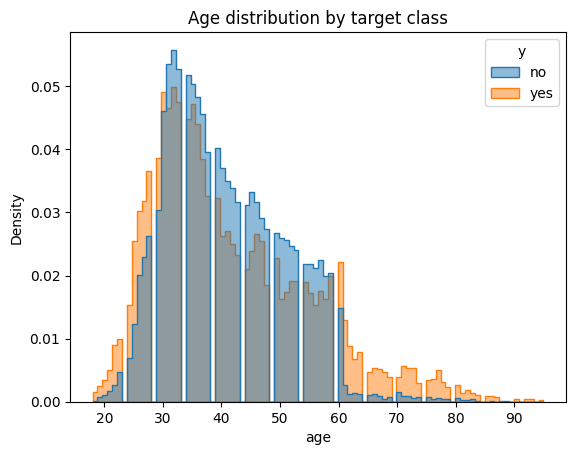

In [15]:
# 5(a)(iv)
# for age and balance, plot histograms split by the target y (overlaid with transparency)
sns.histplot(data=bank, x="age", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Age distribution by target class")

Here, we see the age distributions are relatively similar, but those that said "no" tend to be younger and in their 30s to 60s. Many of those that say "yes" are also generally in the 30s to 60s range, but there are more people in their 60s to 90s that said "yes." 

Text(0.5, 1.0, 'Balance distribution by target class')

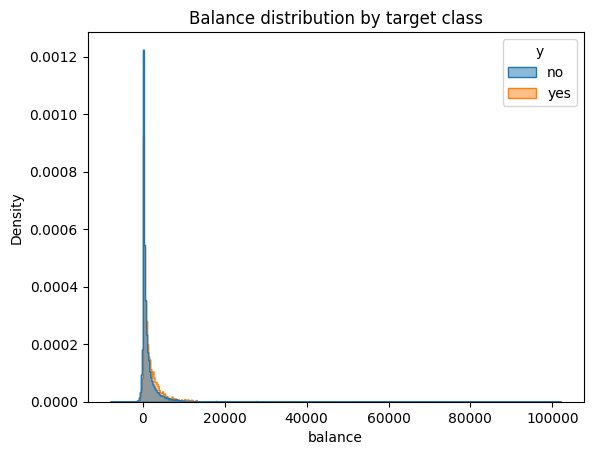

In [16]:
sns.histplot(data=bank, x="balance", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Balance distribution by target class")

Here, we see that for both "yes" and "no", the balance is highly concentrated at and near 0, with very few people at 20000 or higher, but still some sitting there. 

C:\Users\thebr\AppData\Local\Temp\ipykernel_36160\1106139440.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)


Text(0.5, 1.0, 'Subscription rate by previous outcome')

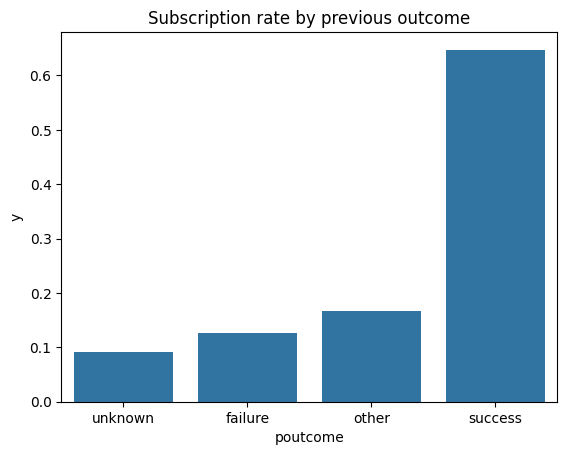

In [17]:
# do the same for "poutcome" using a bar chart of subscription rate per category
sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)
plt.title("Subscription rate by previous outcome")

Here, we see that if the previous outcome was a "success", the subscription rate was very high, and if not a success, then the subscription rate was relatively low (at or below 0.2).

In [ ]:
# 5(b)(i)